In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

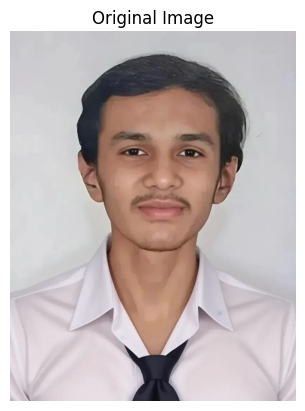

In [2]:
img = cv2.imread("PARTH_passport_size.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

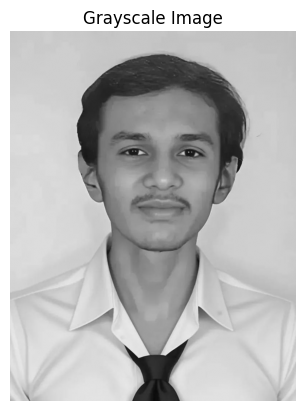

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

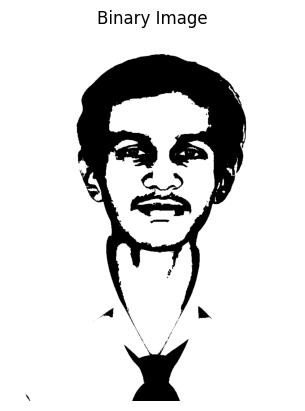

In [4]:
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis("off")

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

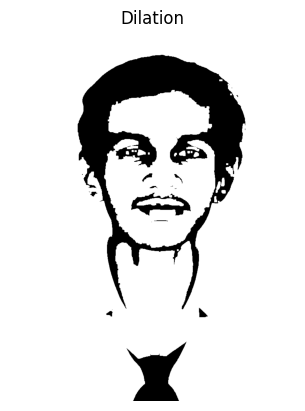

In [5]:
kernel = np.ones((5,5), np.uint8)

dilated = cv2.dilate(binary, kernel, iterations=1)

plt.imshow(dilated, cmap='gray')
plt.title("Dilation")
plt.axis("off")

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

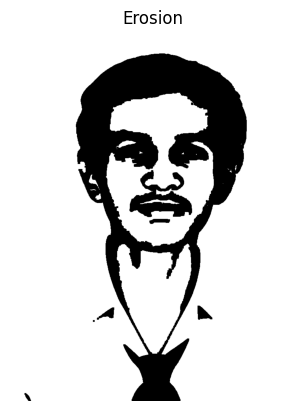

In [6]:
eroded = cv2.erode(binary, kernel, iterations=1)

plt.imshow(eroded, cmap='gray')
plt.title("Erosion")
plt.axis("off")

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

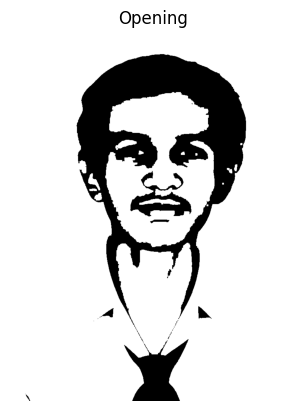

In [7]:
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

plt.imshow(opening, cmap='gray')
plt.title("Opening")
plt.axis("off")

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

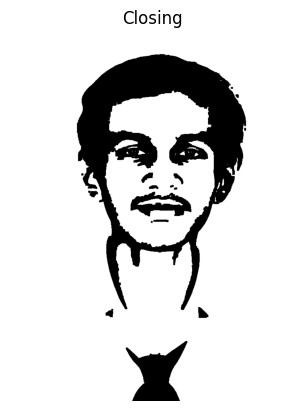

In [8]:
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.imshow(closing, cmap='gray')
plt.title("Closing")
plt.axis("off")

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

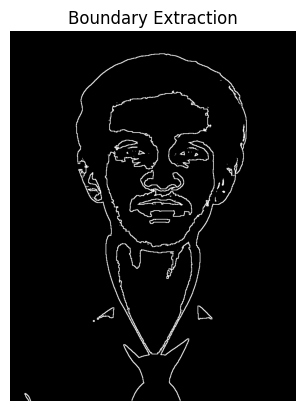

In [9]:
boundary = cv2.subtract(binary, cv2.erode(binary, kernel))

plt.imshow(boundary, cmap='gray')
plt.title("Boundary Extraction")
plt.axis("off")

Number of significant components: 5


(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

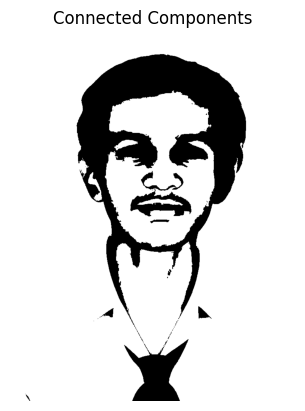

In [10]:
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)

output = np.zeros(binary.shape, dtype=np.uint8)
count = 0

for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] > 500:
        output[labels == i] = 255
        count += 1

print("Number of significant components:", count)

plt.imshow(output, cmap='gray')
plt.title("Connected Components")
plt.axis("off")

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

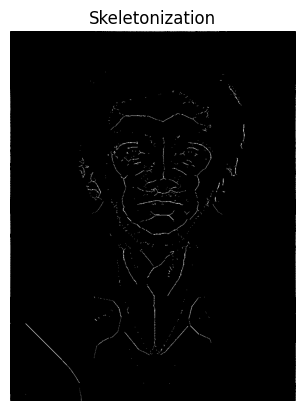

In [11]:
def thinning_cv2(img):
    img = img.copy()
    img[img > 0] = 255

    skel = np.zeros(img.shape, np.uint8)
    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))

    while True:
        eroded = cv2.erode(img, element)
        opened = cv2.dilate(eroded, element)
        temp = cv2.subtract(img, opened)
        skel = cv2.bitwise_or(skel, temp)
        img = eroded.copy()

        if cv2.countNonZero(img) == 0:
            break

    return skel

skeleton = thinning_cv2(binary)

plt.imshow(skeleton, cmap='gray')
plt.title("Skeletonization")
plt.axis("off")

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

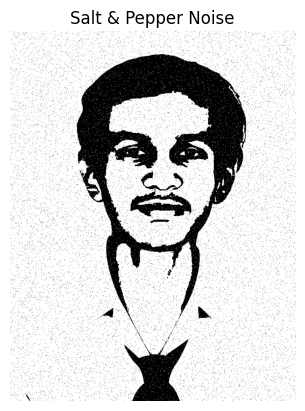

In [12]:
noisy = binary.copy()
rows, cols = noisy.shape

num_noise = int(0.05 * rows * cols)

for i in range(num_noise):
    x = np.random.randint(0, rows)
    y = np.random.randint(0, cols)
    noisy[x, y] = 255 if np.random.rand() > 0.5 else 0

plt.imshow(noisy, cmap='gray')
plt.title("Salt & Pepper Noise")
plt.axis("off")

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

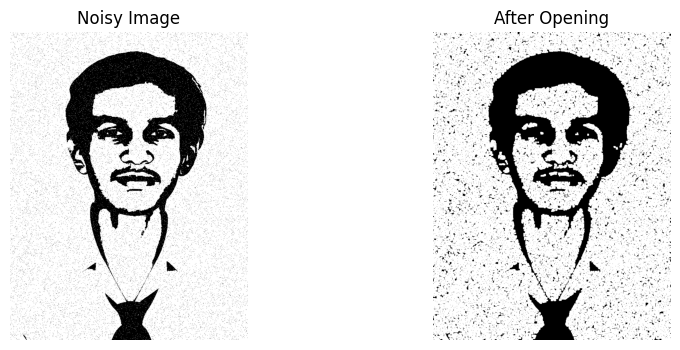

In [13]:
denoised = cv2.morphologyEx(noisy, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(denoised, cmap='gray')
plt.title("After Opening")
plt.axis("off")

(np.float64(-0.5), np.float64(789.5), np.float64(1023.5), np.float64(-0.5))

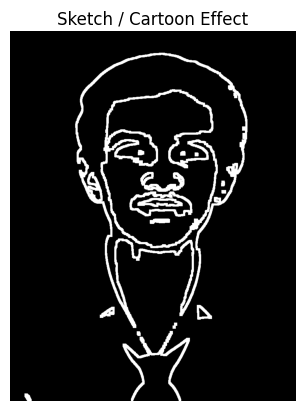

In [14]:
_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

open_img = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

boundary_img = cv2.subtract(open_img, cv2.erode(open_img, kernel))

cartoon = cv2.dilate(boundary_img, kernel)

plt.imshow(cartoon, cmap='gray')
plt.title("Sketch / Cartoon Effect")
plt.axis("off")